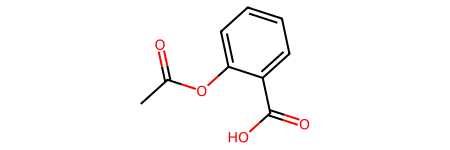

In [1]:
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, AllChem

aspirin = Chem.MolFromSmiles('CC(=O)Oc1ccccc1C(=O)O')
aspirin

In [2]:
print(f"Molecular weight: {Descriptors.MolWt(aspirin):.2f}")
print(f"LogP:             {Descriptors.MolLogP(aspirin):.2f}")
print(f"H-bond donors:    {Descriptors.NumHDonors(aspirin)}")
print(f"H-bond acceptors: {Descriptors.NumHAcceptors(aspirin)}")
print(f"Rotatable bonds:  {Descriptors.NumRotatableBonds(aspirin)}")
print(f"TPSA:             {Descriptors.TPSA(aspirin):.2f}")

Molecular weight: 180.16
LogP:             1.31
H-bond donors:    1
H-bond acceptors: 3
Rotatable bonds:  2
TPSA:             63.60


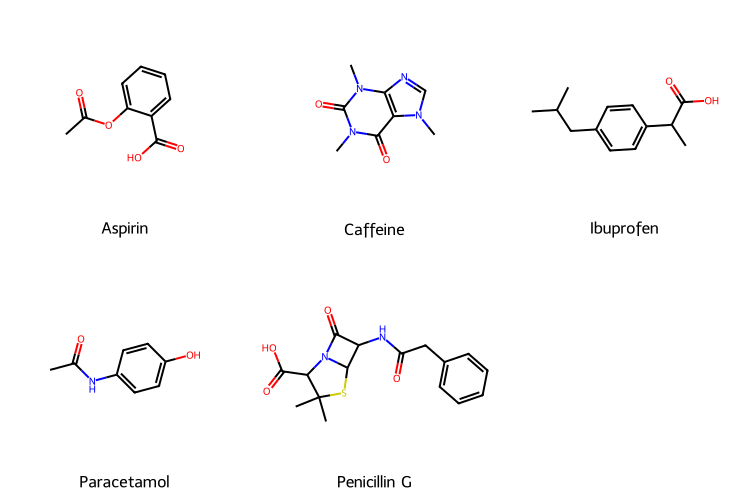

In [3]:
smiles_dict = {
    'Aspirin':    'CC(=O)Oc1ccccc1C(=O)O',
    'Caffeine':   'CN1C=NC2=C1C(=O)N(C(=O)N2C)C',
    'Ibuprofen':  'CC(C)Cc1ccc(cc1)C(C)C(=O)O',
    'Paracetamol':'CC(=O)Nc1ccc(O)cc1',
    'Penicillin G':'CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O',
}

mols = [Chem.MolFromSmiles(s) for s in smiles_dict.values()]
Draw.MolsToGridImage(mols, molsPerRow=3, legends=list(smiles_dict.keys()), subImgSize=(250, 250))

In [10]:
import pandas as pd

mollist = []
for k, v in smiles_dict.items():
    mol = Chem.MolFromSmiles(v)
    moldict = {}
    moldict["molecule_name"] = k
    moldict["molecule_smiles"] = v
    moldict["molecular_weight"] = Descriptors.MolWt(mol)
    moldict["logp"] = Descriptors.MolLogP(mol)
    moldict["hbd"] = Descriptors.NumHDonors(mol)
    moldict["hba"] = Descriptors.NumHAcceptors(mol)
    moldict["rotatable_bonds"] = Descriptors.NumRotatableBonds(mol)
    moldict["tpsa"] = Descriptors.TPSA(mol)
    mollist.append(moldict)
    
    
dataset = pd.DataFrame(mollist)
dataset
    

,molecule_name,molecule_smiles,molecular_weight,logp,hbd,hba,rotatable_bonds,tpsa
0,Aspirin,CC(=O)Oc1ccccc1C(=O)O,180.159,1.3101,1,3,2,63.60
1,Caffeine,CN1C=NC2=C1C(=O)N(C(=O)N2C)C,194.194,-1.0293,0,3,0,61.82
2,Ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.285,3.0732,1,1,4,37.30
3,Paracetamol,CC(=O)Nc1ccc(O)cc1,151.165,1.3506,2,2,1,49.33
4,Penicillin G,CC1(C)SC2C(NC(=O)Cc3ccccc3)C(=O)N2C1C(=O)O,334.397,0.8608,2,4,4,86.71
